In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.tile.bin_1d import Tile2Symb1dBin

from tests.experimental.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 10
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]


def make_converter(params: Params):
    return Tile2Symb1dBin(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: -0.0240 | Max: 0.0509 | Mean: 0.0158 | Std: 0.0262
Min: 0.0347 | Max: 0.1449 | Mean: 0.0888 | Std: 0.0380
Min: 0.0071 | Max: 0.1823 | Mean: 0.1064 | Std: 0.0509
Min: 0.0125 | Max: 0.1644 | Mean: 0.0935 | Std: 0.0488
Min: 0.0108 | Max: 0.1719 | Mean: 0.0944 | Std: 0.0531
Min: 0.0262 | Max: 0.1676 | Mean: 0.0943 | Std: 0.0478
Min: 0.0251 | Max: 0.1538 | Mean: 0.0941 | Std: 0.0451
Min: 0.0126 | Max: 0.1556 | Mean: 0.0983 | Std: 0.0463
Min: 0.0319 | Max: 0.1716 | Mean: 0.1037 | Std: 0.0440


C:\Users\wojte\AppData\Local\Temp\ipykernel_3376\4009546293.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


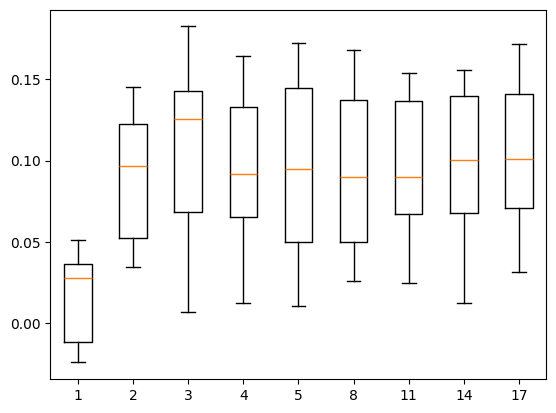

In [2]:
# bins

params_space = [
    bins for bins in range(1, 5, 1)
]
params_space += [
    bins for bins in range(5, 18, 3)
]

params_space = list(
    map(lambda bins: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={'bins': bins},
        preprocess_args={}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['bins'] for param in params_space])
plt.show()

Min: 0.0079 | Max: 0.1218 | Mean: 0.0609 | Std: 0.0361
Min: 0.0123 | Max: 0.1402 | Mean: 0.0902 | Std: 0.0447
Min: 0.0568 | Max: 0.1847 | Mean: 0.1205 | Std: 0.0446
Min: 0.0783 | Max: 0.1968 | Mean: 0.1358 | Std: 0.0458
Min: 0.0851 | Max: 0.2205 | Mean: 0.1483 | Std: 0.0482


C:\Users\wojte\AppData\Local\Temp\ipykernel_3376\549677722.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


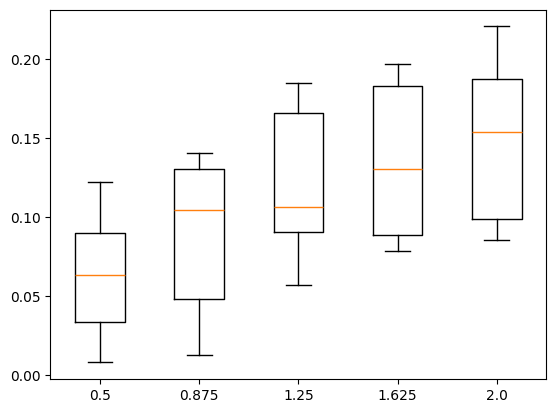

In [3]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [8]:
import math
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery
from converters.img_converter import ImgConverter


converter = Tile2Symb1dBin(symbols=SYMBOLS,
                           font=ImageFont.truetype(FONT_PATH, FONT_SIZE))

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = ImgConverter(converter).img2symbols(img, (3, 6), MAX_WIDTH, MAX_HEIGHT)
    results.append(res_arr)

print_gallery(results, 2)

---------------------------------------------------------------
 | _'"^"^"\=rvi!""1+vr\^/^^^-` | (h%aqOPe4{=LW2E#R@N$&5cHQ@i | 
 | _"::_;:^=^'_--`-,---. `` .  | r+>r+F5n4+|"4+[%X2AZ4})ow=- | 
 | wZbkWKH@@888WWW@KWKKq6X4Ae| | __^^i25D5J)-^~^v+tt~!/""^^, | 
 | 4PbK@HK@#88WW@H@K8@KHXXd5hv | r)>7lS%S?;^"-`. "\(c)Jlt}c" | 
 | hq@KW&6,'''^L@@HKW8H8W9bS41 | ?vii7eSZOx^`  . 'It}Tttoa}~ | 
 | ADq88df?eoI?sbW@8#PUwAA5Zu| | |cI}fa44wZi-``. ^ataf{<*+!' | 
 | zwZ9pU#U6qKKKK#PPG6k6EhZVe\ | "{Lltaj55ZL_`...!tLeahZIl/: | 
 | 9bKWQ&gKW8$&g&&R8@K9OA553Y\ | vT7t{2S45hy_```^>/"/{Lxtfs, | 
 | bWWBggMHRKQMQH@K8mdk#UShya" | i)((+7FJZA4_-:rJ*---"1>t?<, | 
---------------------------------------------------------------
 | Tl3t]t>",':"^{?ri1|f2SL!:-. | .` ..------- | 
 | ^^!"^":,:^^"i!=^^,;:;-----` | :,_:^"~,:~'' | 
 | /*\\1r!^r1^"*1>|^^^^^""':^- | 7}LLJx77f7l{ | 
 | \|r1c{1L5u4w@WEe4C|+I5W98W" | 7{zs}nJiC77J | 
 | >|!cr"|l{t?1)2lt?f}t}v'c2>~ | xoIV=\>^nzCa | 
 | )(/*/\: --"^1>v|\=/*_"';" . | TjVe"-  /y{f | 
 |